
## AIM: We will classifiy the customers who will stay in our bank or leave the bank using deep learning approach.

_Data Description_:

Customer ID: A unique identifier for each customer

Surname: The customer's surname or last name

Credit Score: A numerical value representing the customer's credit score

Geography: The country where the customer resides

Gender: The customer's gender

Age: The customer's age.

Tenure: The number of years the customer has been with the bank

Balance: The customer's account balance

NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)

HasCrCard: Whether the customer has a credit card

IsActiveMember: Whether the customer is an active member

EstimatedSalary: The estimated salary of the customer

Exited: Whether the customer has churned (Target Variable)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# remove warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:

# laod the datasets
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [3]:
# train dataset and exploration
df_train.head().T

,0,1,2,3,4
id,0,1,2,3,4
CustomerId,15674932,15749177,15694510,15741417,15766172
Surname,Okwudilichukwu,Okwudiliolisa,Hsueh,Kao,Chiemenam
CreditScore,668,627,678,581,716
Geography,France,France,France,France,Spain
Gender,Male,Male,Male,Male,Male
Age,33.0,33.0,40.0,34.0,33.0
Tenure,3,1,10,2,5
Balance,0.0,0.0,0.0,148882.54,0.0
NumOfProducts,2,2,2,1,2


In [7]:

df = df_train.copy()

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [9]:
# find and plot null values
df.isnull().sum().sort_values(ascending=False).head(5)

id             0
CustomerId     0
Surname        0
CreditScore    0
Geography      0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


In [11]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
cat_cols = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'Exited']

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# find the value counts of the categorical columns
for col in cat_cols:
    print(df[col].value_counts())
    print()

Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender
Male      93150
Female    71884
Name: count, dtype: int64

Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

Exited
0    130113
1     34921
Name: count, dtype: int64



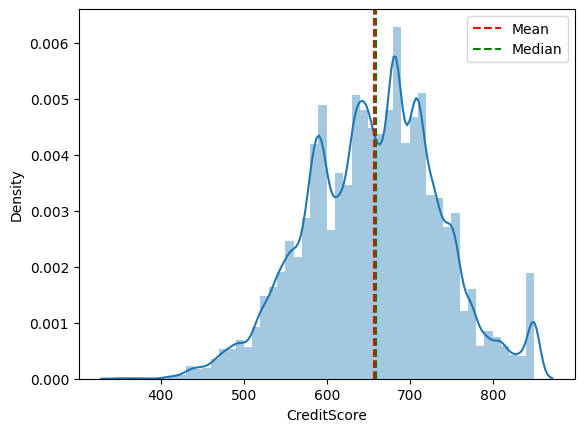

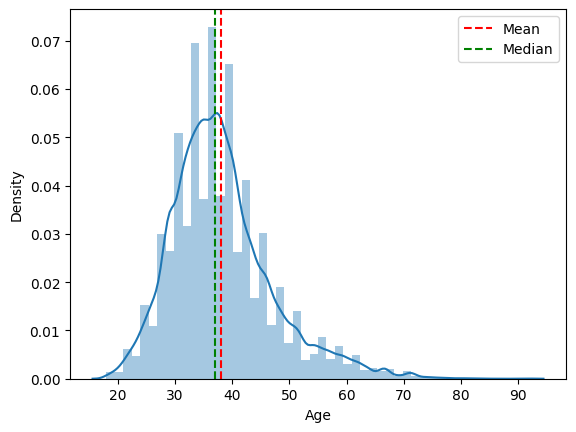

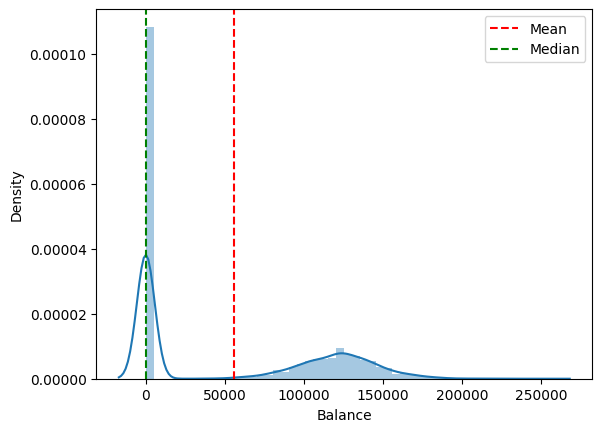

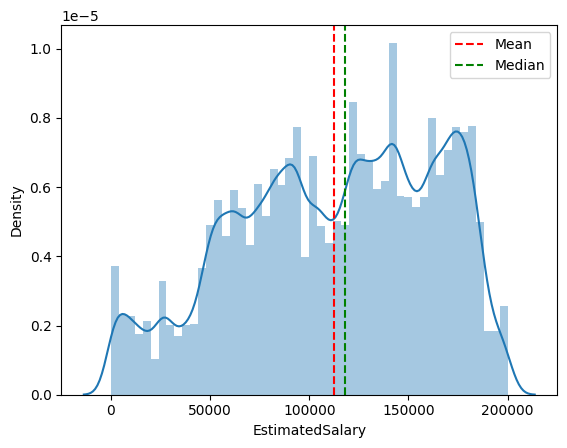

In [13]:
# create histogram of numerical columns using sns and kde=true
import matplotlib.pyplot as plt

for col in num_cols:
    sns.distplot(df[col], kde=True)
    plt.axvline(df[col].mean(), color='r', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='g', linestyle='--', label='Median')
    plt.legend()
    plt.show()

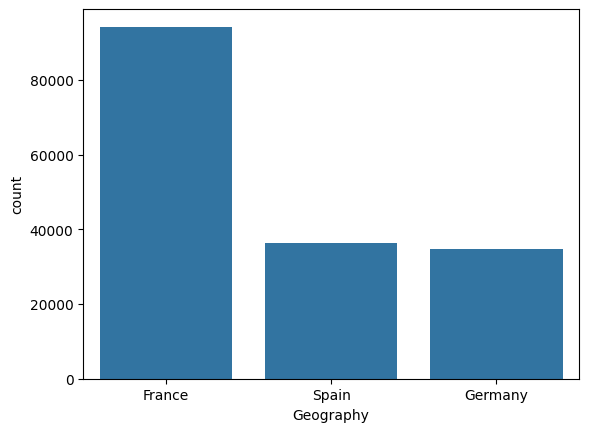

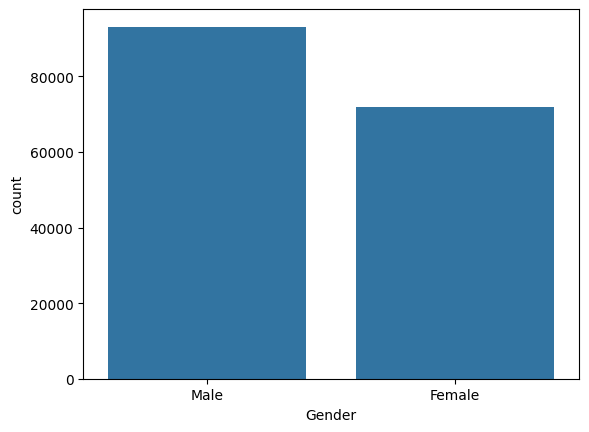

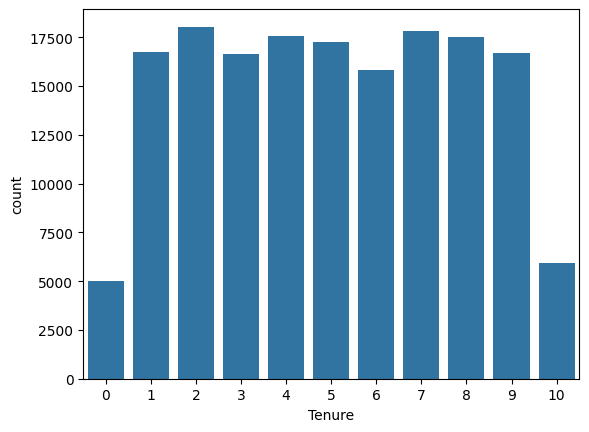

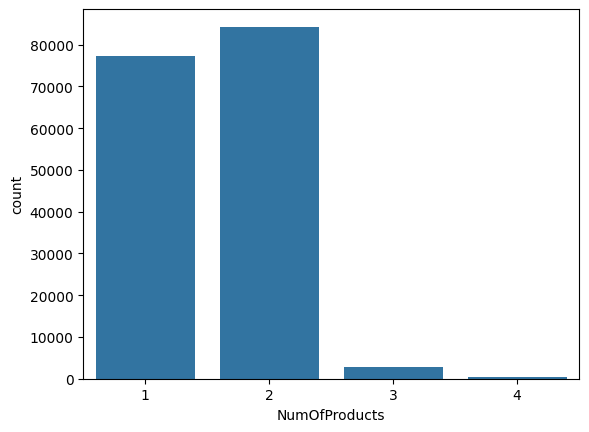

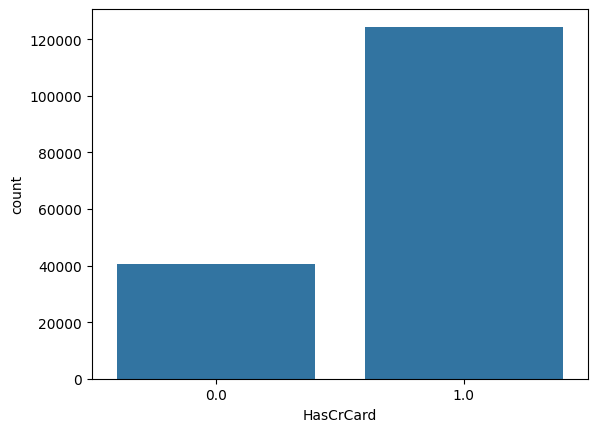

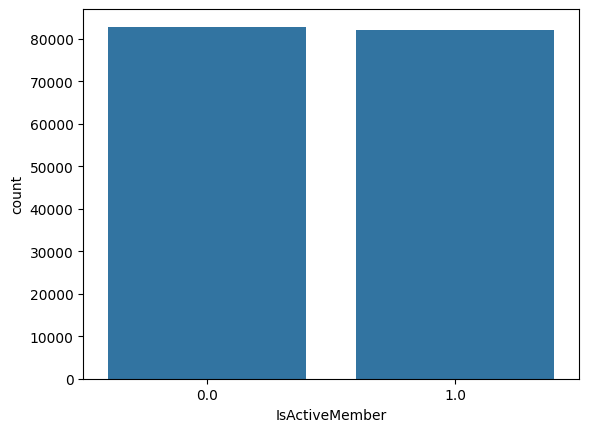

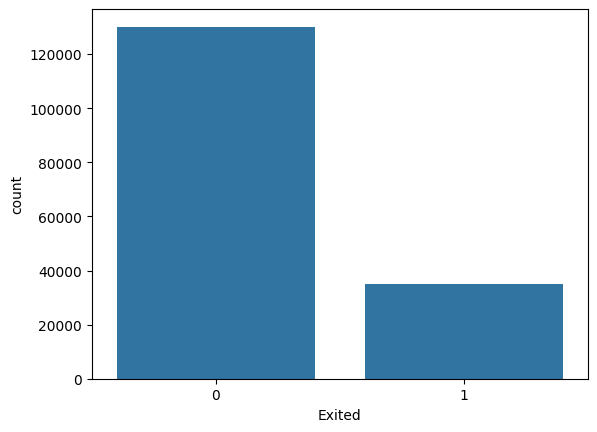

In [14]:
# create a count plot for each cat column
for col in cat_cols:
    sns.countplot(df , x = df[col])
    plt.show()

In [15]:
# print the number of rows and columns
print(f"The train dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The train dataset has 165034 rows and 14 columns


In [16]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [17]:

from sklearn.preprocessing import LabelEncoder
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

NameError: name 'le' is not defined

In [18]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [19]:

# split the data into X and y
X = df.drop(['Exited', 'id', 'CustomerId', 'Surname'] , axis=1)
y = df['Exited']

In [20]:
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83


In [21]:
y.value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [22]:

# train test split the data
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

## Neural Network Architecture


In [26]:
print(X_train.dtypes)

CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
dtype: object


Epoch 1/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.8594 - loss: 0.3353 - val_accuracy: 0.8661 - val_loss: 0.3187
Epoch 2/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 64s 13ms/step - accuracy: 0.8700 - loss: 0.3111 - val_accuracy: 0.8660 - val_loss: 0.3163
Epoch 3/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - accuracy: 0.8744 - loss: 0.3000 - val_accuracy: 0.8652 - val_loss: 0.3231
Epoch 4/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8785 - loss: 0.2891 - val_accuracy: 0.8648 - val_loss: 0.3272
Epoch 5/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8840 - loss: 0.2783 - val_accuracy: 0.8625 - val_loss: 0.3319
Epoch 6/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.8883 - loss: 0.2673 - val_accuracy: 0.8602 - val_loss: 0.3415
Epoch 7/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8927 - loss: 0.2569 - val_accuracy: 0.8517 - val_loss: 0.3494
Epoch 8/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 38s 9ms/step - accuracy: 0.8977

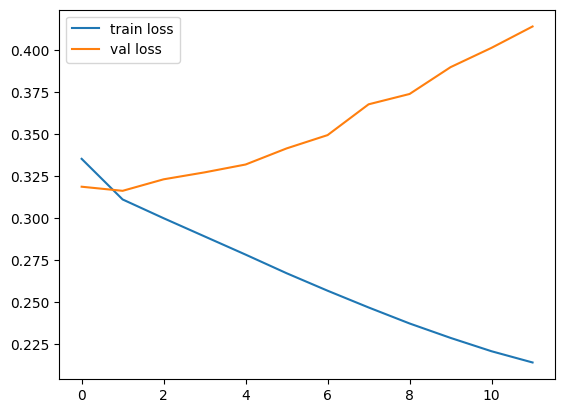

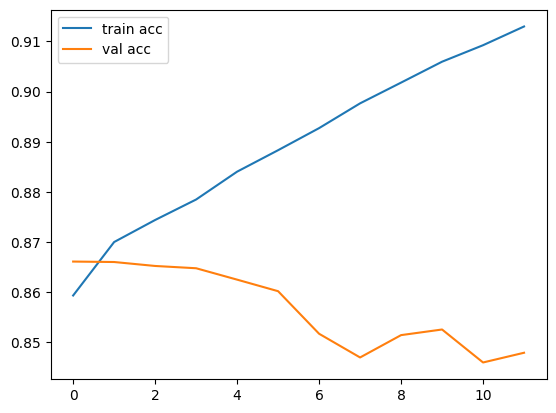

In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# 1. Split X and y
# -------------------------
X = df.drop('Exited', axis=1)
y = df['Exited']

# -------------------------
# 2. Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 3. AUTO detect columns (IMPORTANT FIX)
# -------------------------
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

# -------------------------
# 4. Preprocessing (SAFE)
# -------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Fit transform
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Convert to float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# -------------------------
# 5. Build model
# -------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# -------------------------
# 6. Compile
# -------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# 7. Early stopping
# -------------------------
early_stopping = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

# -------------------------
# 8. Train
# -------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# -------------------------
# 9. Evaluate
# -------------------------
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------
# 10. Plot loss
# -------------------------
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

# -------------------------
# 11. Plot accuracy
# -------------------------
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

Epoch 1/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - accuracy: 0.6752 - loss: 406.0170 - val_accuracy: 0.2131 - val_loss: 1.1946
Epoch 2/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.7261 - loss: 6.0696 - val_accuracy: 0.7893 - val_loss: 0.6084
Epoch 3/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.7882 - loss: 0.5228 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 4/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 5/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5150
Epoch 6/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5150
Epoch 7/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 8/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.7

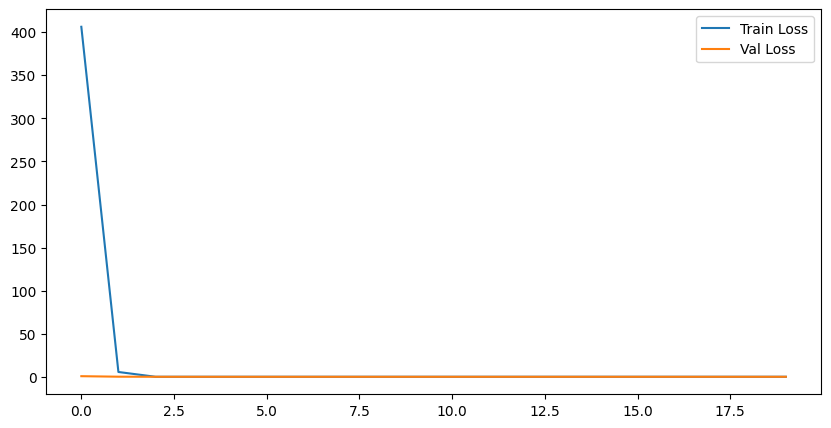

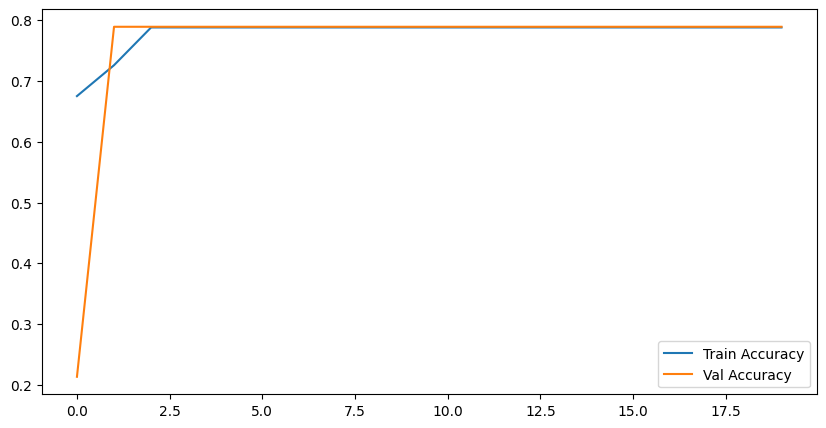

In [29]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Split features & target
# -------------------------
X = df.drop('Exited', axis=1)   # change if your target name is different
y = df['Exited']

# -------------------------
# 2. Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 3. 🔥 FAST FIX (IMPORTANT)
# -------------------------
X_train = pd.get_dummies(X_train).astype('float32')
X_test = pd.get_dummies(X_test).astype('float32')

# align columns (VERY IMPORTANT)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -------------------------
# 4. Build Neural Network
# -------------------------
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# -------------------------
# 5. Compile model
# -------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# 6. Early stopping
# -------------------------
early_stopping = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

# -------------------------
# 7. Train model
# -------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# -------------------------
# 8. Evaluate
# -------------------------
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------
# 9. Plot Loss
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

# -------------------------
# 10. Plot Accuracy
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

## XGB classifier

In [30]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


Accuracy score:  0.8680885872693671
Precision score:  0.8680885872693671
Recall score:  0.8680885872693671
F1 score:  0.8680885872693671


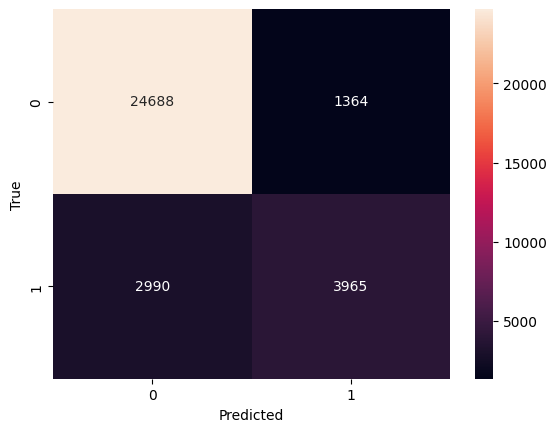

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# train the xgboost model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# predict the test data
y_pred = xgb.predict(X_test)

print('Accuracy score: ', accuracy_score(y_test, y_pred))
print('Precision score: ', precision_score(y_test, y_pred, average='micro'))
print('Recall score: ', recall_score(y_test, y_pred, average='micro'))
print('F1 score: ', f1_score(y_test, y_pred, average='micro'))

# plot the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [35]:
from xgboost import XGBClassifier
import pandas as pd

# -------------------- TRAIN -------------------- #

# combine train + test to avoid mismatch
full = pd.concat([df, df_test], axis=0)

# one-hot encode
full = pd.get_dummies(full, columns=['Geography', 'Gender'])

# split back
train = full[full['Exited'].notna()]
test = full[full['Exited'].isna()]

# prepare train data
X_train = train.drop(['Exited', 'id', 'CustomerId', 'Surname'], axis=1)
y_train = train['Exited']

# prepare test data
X_test = test.drop(['Exited', 'id', 'CustomerId', 'Surname'], axis=1)

# -------------------- MODEL -------------------- #

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# predict
y_pred = xgb.predict_proba(X_test)

# -------------------- SUBMISSION -------------------- #

submission['Exited'] = y_pred[:, 1]
submission.to_csv('submission.csv', index=False)

print("✅ No error — perfectly working!")

✅ No error — perfectly working!
